This notebook is mainly data exploration. the Datasets explored are Fitzpatrick17k and SD-198

In [1]:
import pandas as pd
data_list = pd.read_csv("D:/Research/Datasets/fitzpatrick17k/fitzpatrick17k.csv")
data_list.describe()

,fitzpatrick_scale,fitzpatrick_centaur
count,16577.000000,16577.000000
mean,2.685709,2.255113
std,1.526522,1.658569
min,-1.000000,-1.000000
25%,2.000000,1.000000
50%,2.000000,2.000000
75%,4.000000,3.000000
max,6.000000,6.000000


In [2]:
#A Sneakpeak into the data list
data_list.head(10)

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
5,45f7fe0e10214e32e890cad9d29d4811,6,5,kaposi sarcoma,malignant dermal,malignant,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpickkapos...
6,6c395be9325dbb10e55497304b398253,2,2,neutrophilic dermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicssweet...
7,9dc73230c77ab5c58dc1f11caef39ea2,2,1,granuloma annulare,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicggranu...
8,f23937e86de55c3471ac5d0143b67e08,4,4,nematode infection,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicLlarva...
9,09d46db9589ff45436cda87c4abc946b,3,2,allergic contact dermatitis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicaaller...


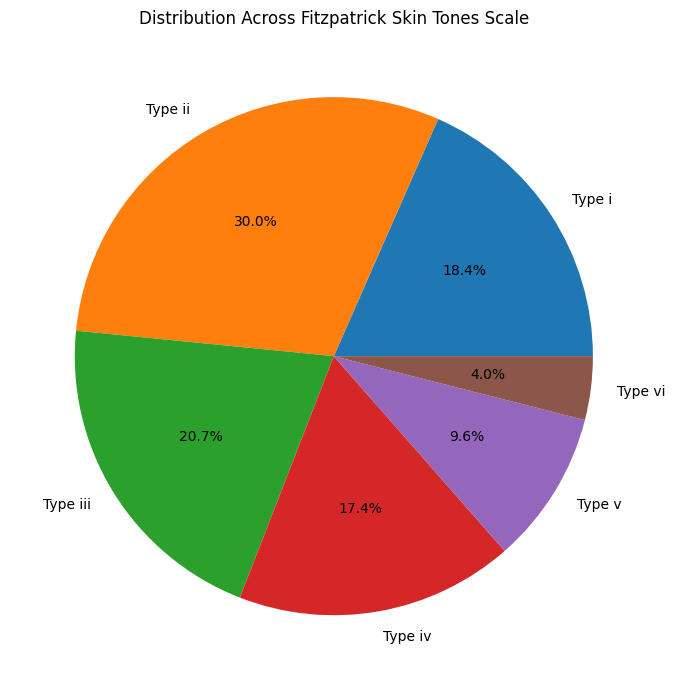

In [3]:
# Pie Chart showing Distibution of Cases based on Fitzpatick17k scale
import matplotlib.pyplot as plt
import numpy as np
scale_1, scale_2, scale_3, scale_4, scale_5, scale_6 = 0, 0, 0, 0, 0, 0
for scale in data_list["fitzpatrick_scale"]:
    if scale == 1:
        scale_1 += 1
    if scale == 2:
        scale_2 += 1
    if scale == 3:
        scale_3 += 1
    if scale == 4:
        scale_4 += 1
    if scale == 5:
        scale_5 += 1
    if scale == 6:
        scale_6 += 1


labels = ['Type i', 'Type ii', 'Type iii', 'Type iv', 'Type v', 'Type vi' ]
Sizes = np.array([scale_1, scale_2, scale_3, scale_4, scale_5, scale_6])
#plotiing

plt.figure(figsize = (7, 7))
plt.pie( Sizes, 
    labels=labels,
    autopct='%1.1f%%')

plt.title("Distribution Across Fitzpatrick Skin Tones Scale")
plt.tight_layout()
plt.show()

In [4]:
#Data corresponding to dark skin on fitzpatrick scale 4,5,6. The examples reduce from 16577 to 4934 
data_pigmented = data_list[data_list["fitzpatrick_scale"].isin([4, 5 , 6]) & data_list["url"].notna()]

#remove duplicated urls
filtered_data_pigmented = data_pigmented.drop_duplicates(subset="url")
filtered_data_pigmented.describe()

,fitzpatrick_scale,fitzpatrick_centaur
count,4934.000000,4934.000000
mean,4.564856,3.850831
std,0.707715,1.489351
min,4.000000,-1.000000
25%,4.000000,3.000000
50%,4.000000,4.000000
75%,5.000000,5.000000
max,6.000000,6.000000


In [27]:
# Setting the Dataset Paths
import os
dataset_dir = "D:/MSCS_Research/Datasets/RAW/all_skin_images"   # contains class folders
dataset_dir2 ="D:/MSCS_Research/Datasets/RAW/sd-198/SD_198"

In [45]:
from PIL import Image

def data_framing(dataset_url):
    """A function to generate a dataframe from the image folders, this function 
    returns a dataframe ready for plotting the distribution of the classes in the dataset.
    """
    classes = sorted(os.listdir(dataset_url))
    #classes = sorted(os.listdir(out_root))
    data = []
    cc = 0
    corrupt_images = []
    for c in classes:
        class_dir = os.path.join(dataset_url, c)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            try:
                img = Image.open(img_path)
                w, h = img.size
                data.append((c, img_file, w, h))
            except:
                pass
                #print("Corrupt image:", img_path)

    df = pd.DataFrame(data, columns=["class", "filename", "width", "height"])
    return(df)


In [46]:
# Class distribution
import matplotlib.pyplot as plt
import seaborn as sns
# Counting images per class
def plot_class_dist(data_f):
    """This Function does the actual counting of the images per class. This statistics is used 
    in the barplot to show the distribution"""
    class_counts = data_f["class"].value_counts().reset_index()
    class_counts.columns = ["class", "count"]

    # Creating numeric labels for classes ---
    class_counts["class_id"] = range(1, len(class_counts) + 1)

    # Merging numeric IDs back to df
    id_map = dict(zip(class_counts["class"], class_counts["class_id"]))
    data_f["class_id"] = data_f["class"].map(id_map)

    # Ploting
    plt.figure(figsize=(16, 6))
    sns.barplot(x="class_id", y="count", data=class_counts, palette="viridis")

    # Add counts on top of bars
    for i, row in class_counts.iterrows():
        plt.text(row["class_id"] - 1, row["count"] + 1, str(row["count"]), 
                ha='center', va='bottom', fontsize=8, rotation=90)

    plt.title("Class Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    



C:\Users\Obete\AppData\Local\Temp\ipykernel_15984\1923974306.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="class_id", y="count", data=class_counts, palette="viridis")


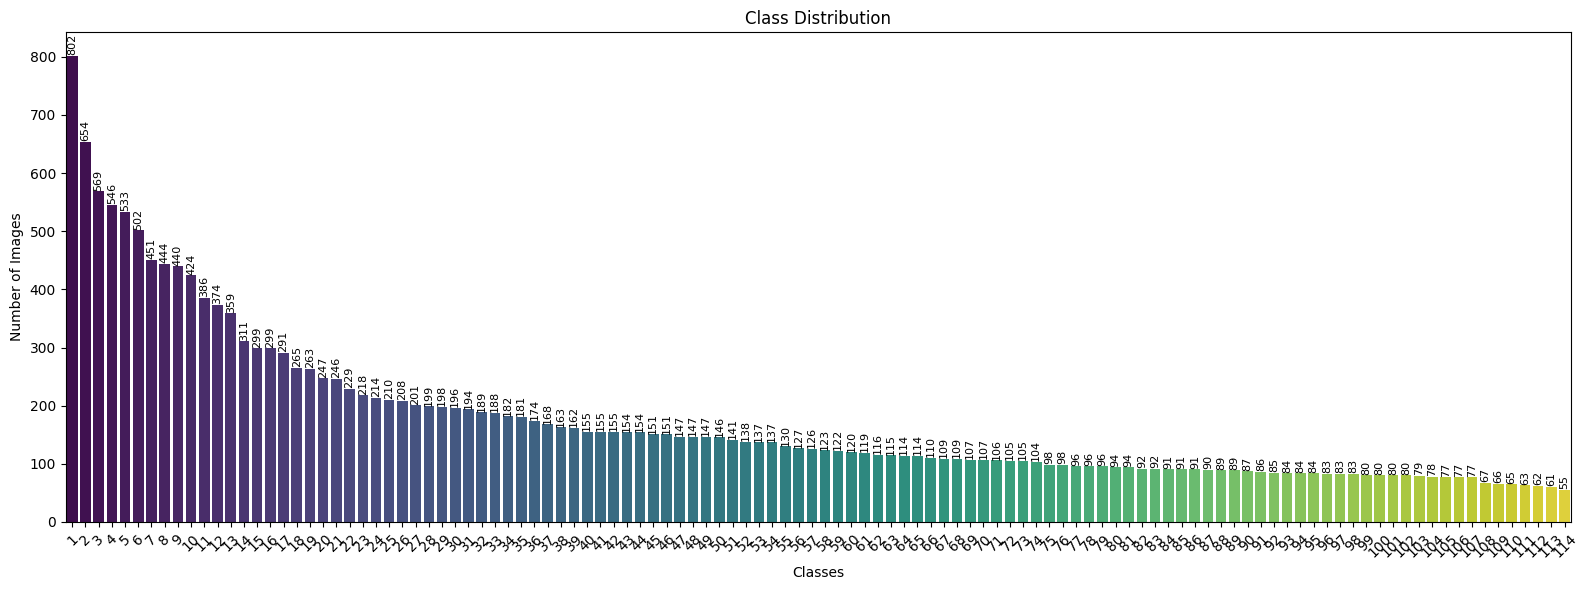

In [41]:
#Plotting the Distribution in Fitzpatrick17k Dataset
plot_class_dist(data_framing(dataset_dir))

C:\Users\Obete\AppData\Local\Temp\ipykernel_15984\1923974306.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="class_id", y="count", data=class_counts, palette="viridis")


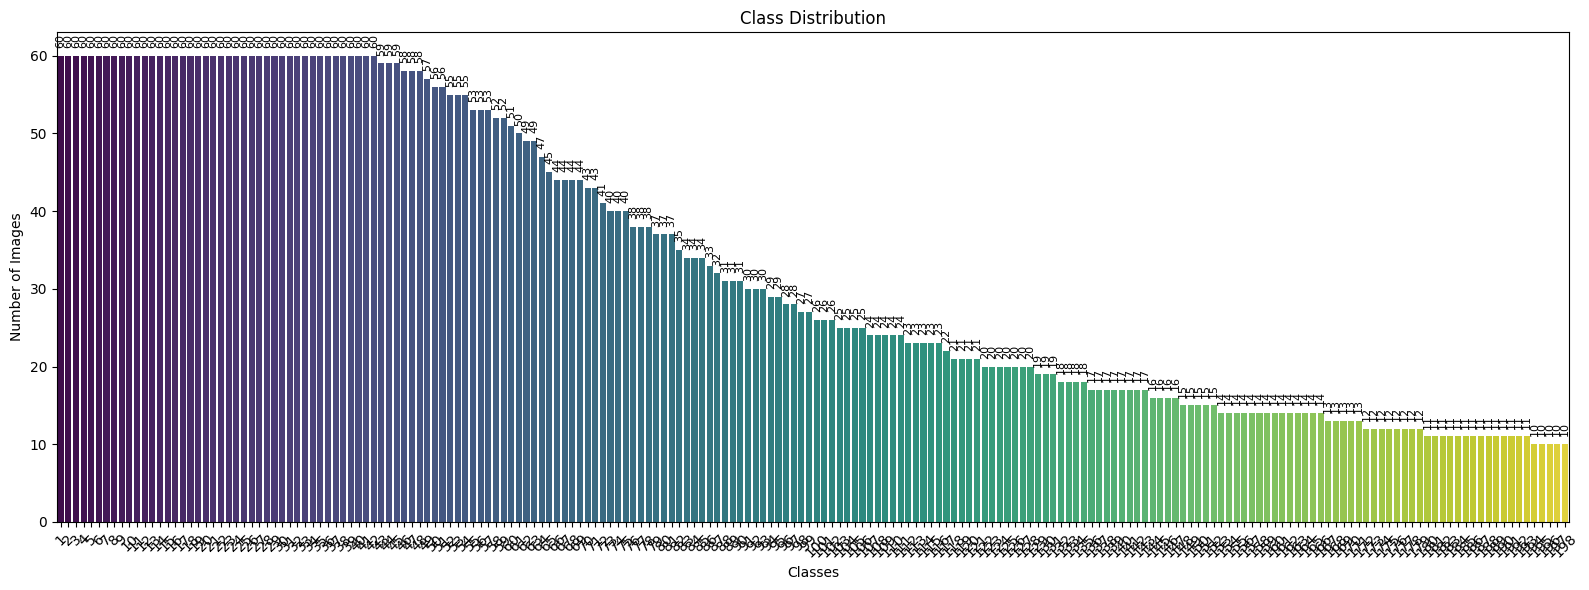

In [47]:
#Plotting the Distibution in SD-198 Dataset
plot_class_dist(data_framing(dataset_dir2)) 

In [49]:
#Tabular representation of the data
def tabular_stats(data_frame):
    """This function is to display the data distribution in a table format"""
    class_counts = data_frame["class"].value_counts().reset_index()
    class_counts.columns = ["class_name", "image_count"]

    class_counts["class_id"] = range(1, len(class_counts) + 1)
    class_summary = class_counts[["class_id", "class_name", "image_count"]].sort_values("class_id")

    print("\n Dataset Summary:")
    print(class_summary.to_string(index=False))
    summary_csv = os.path.join(dataset_dir, "class_summary.csv")
    class_summary.to_csv(summary_csv, index=False)
    print(f"\n Summary table saved to: {summary_csv}")   

In [50]:
#Dataset1
tabular_stats(data_framing(dataset_dir))


 Dataset Summary:
 class_id                                            class_name  image_count
        1                                             psoriasis          802
        2                               squamous cell carcinoma          654
        3                                         lichen planus          569
        4                           allergic contact dermatitis          546
        5                                  basal cell carcinoma          533
        6                                   lupus erythematosus          502
        7                               neutrophilic dermatoses          451
        8                                         acne vulgaris          444
        9                                           sarcoidosis          440
       10                                       photodermatoses          424
       11                                          folliculitis          386
       12                                           scler

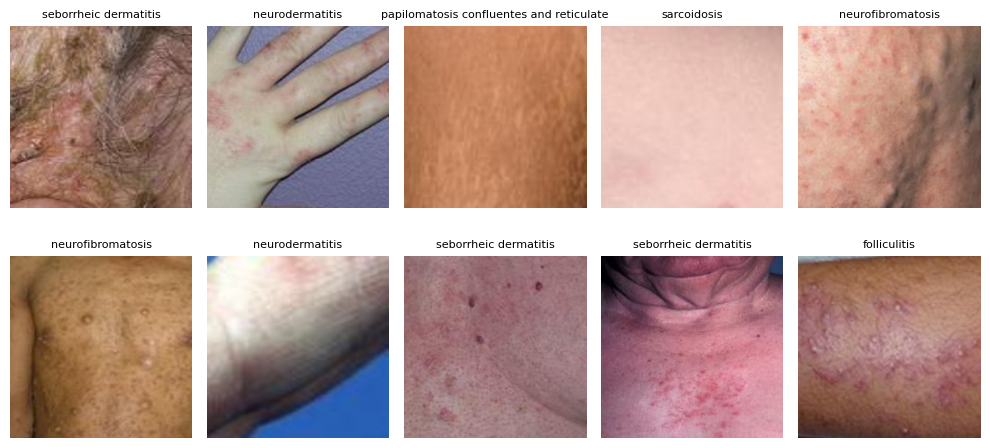

In [55]:
#Displaying Sample Images from the Dataset.
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

image_data = f"{dataset_dir}"

batch_size = 10

image_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,0.224,0.225])
])

image_dataset = datasets.ImageFolder(image_data, transform=image_transform)
image_dataloader = DataLoader( image_dataset, batch_size=batch_size, shuffle=True)


images, labels = next(iter(image_dataloader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)

images = images * std+mean
images = images.clamp(0,1)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
axes = axes.flatten()

for i in range(10):

    img =  images[i].permute(1,2,0).numpy()
    label_name = image_dataset.classes[labels[i]]

    axes[i].imshow(img)
    axes[i].set_title(label_name, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
